Import Library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import os
import logging
import time
import seaborn as sns

from matplotlib.backend_tools import cursors
from sqlalchemy import create_engine, text
from sqlalchemy.dialects.mysql import LONGTEXT
from sqlalchemy.exc import SQLAlchemyError
from datetime import datetime
import folium                        ## for plot map
from geopy.geocoders import Nominatim      ## for longitude and latitude of city or state
from matplotlib.colors import LinearSegmentedColormap   ## customize map colour
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [2]:
DB_USER     = "root"
DB_PASSWORD = "1234"     # Changed to string
DB_HOST     = "127.0.0.1"
DB_PORT     = 3306
DB_NAME     = "yelp_db"

# Connect to MySQL without database first to ensure DB exists
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
# pd.read_sql("USE yelp_db",engine)
tables=pd.read_sql("Show Tables",engine).reset_index()



In [3]:
# Explore what type of data available in the tables:
for tb in tables['Tables_in_yelp_db']:
    display(pd.read_sql_query(f"SELECT * FROM {tb} LIMIT 5",engine))


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"{""ByAppointmentOnly"": ""True""}","Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"{""BusinessAcceptsCreditCards"": ""True""}","Shipping Centers, Local Services, Notaries, Ma...","{""Monday"": ""0:0-0:0"", ""Tuesday"": ""8:0-18:30"", ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{""BikeParking"": ""True"", ""BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{""Monday"": ""8:0-22:0"", ""Tuesday"": ""8:0-22:0"", ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{""RestaurantsDelivery"": ""False"", ""OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{""Monday"": ""7:0-20:0"", ""Tuesday"": ""7:0-20:0"", ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{""BusinessAcceptsCreditCards"": ""True"", ""Wheelc...","Brewpubs, Breweries, Food","{""Wednesday"": ""14:0-22:0"", ""Thursday"": ""16:0-2..."


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,AW0tVcfwYZBiwtwYyaX0WA,Melissa,307,2009-01-08 23:55:17,582,142,300,"2010,2011,2012,2013,2014,2015,2016","ya3mbvTaymecfrTc08SxhQ, GqHrL09yyKXq1OHa8DhDPQ...",25,...,7,4,1,0,17,22,28,28,20,1
2,lf1m4CbheuUR7fFZoLGRvA,Rick,1126,2007-11-18 20:40:12,4743,2119,3481,"2008,2009,2010,2011,2012,2013,2014,2015,2016,2...","UwdoumbX2bCuzbfL4AyWHg, K_nUNqclUH0M_fvkxasjsA...",156,...,35,22,26,15,116,178,279,279,147,21
3,S0xQEAwvL2_XCdS06xEmQA,liamrh,39,2010-06-20 17:49:57,61,6,8,,"wTGWx7mjQHfsx9nFWcuuOw, Bi9KOYtWU0irUGrtLDcKBw...",0,...,0,0,0,0,1,1,0,0,0,1
4,9vfvjqAXMyeSxTV2__GFNw,Roy,5,2010-03-21 15:47:01,6,4,2,,"0PzfaqxAXApP7qJtYEDy_w, FN72q7fcszebjIy3f-__Ig...",0,...,0,0,0,0,0,0,1,1,0,0


,business_id,name,city,state,stars,review_count,categories
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea..."
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,Affton,MO,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr..."
3,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,..."
4,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks"


,business_id,date
0,--ZVrH2X2QXBFdCilbirsw,"2010-08-12 18:21:29, 2010-08-20 17:49:17, 2012..."
1,--hF_3v1JmU9nlu4zfXJ8Q,"2021-09-15 16:08:07, 2021-09-30 17:10:48, 2021..."
2,-2Axhv9AZ_n7qjQefECpVw,"2015-06-10 00:51:46, 2015-06-13 18:42:01, 2015..."
3,-2ke_JDOpgTZWqirMFjZcw,"2013-05-19 01:25:07, 2013-05-25 01:34:13, 2013..."
4,-3-6BB10tIWNKGEF0Es2BA,"2020-09-09 21:54:07, 2020-09-09 22:12:01, 2020..."


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
2,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
3,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16
4,OAhBYw8IQ6wlfw1owXWRWw,1C2lxzUo1Hyye4RFIXly3g,BVndHaLihEYbr76Z0CMEGw,5,0,0,0,"Great place for breakfast! I had the waffle, w...",2014-10-11 16:22:06


,user_id,business_id,text,date,compliment_count
0,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
1,JsXhBw6MntzTJjH_Ue5udw,wLHodvVFLTgK3nl2XG8OCw,Very good will definitely be coming back!!,2017-03-23 22:01:41,0
2,Ba1I_wRHRQzvuyFU4PwPrw,ZhCnKe7U1TsHWnAlXl8Isw,The pimento cheese tastes great and is a large...,2016-05-02 17:59:57,0
3,nhXyjGOCfi-EW09bJqfAzQ,1Efad30BdOeqqjX2d6P4sw,You MUST have the popover breakfast!!,2015-05-23 13:33:04,1
4,8ohYIH9wHjKdWc4yAROqBw,3w7NRntdQ9h0KwDsksIt5Q,Just in the nik before the mad hyper kids rush...,2013-03-09 19:23:16,0


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


## Data Analysis

In [4]:
pd.read_sql_query("select count(*) from business",engine)

,count(*)
0,150346


In [5]:
ids = pd.read_sql_query("""SELECT business_id,review_count,stars
FROM business
WHERE LOWER(categories) LIKE '%%restaurant%%'
AND is_open = 1""",engine)
ids






,business_id,review_count,stars
0,MTSW4McQd7CbVtyjqoe9mw,80,4.0
1,CF33F8-E6oudUQ46HnavjQ,6,2.0
2,bBDDEgkFA1Otx9Lfe7BZUQ,10,1.5
3,eEOYSgkmpB90uNA7lDOMRA,10,4.0
4,il_Ro8jwPlHresjw9EGmBg,28,2.5
...,...,...,...
34999,w_4xUt-1AyY2ZwKtnjW0Xg,998,4.5
35000,l9eLGG9ZKpLJzboZq-9LRQ,11,3.0
35001,cM6V90ExQD6KMSU3rRB5ZA,33,4.0
35002,WnT9NIzQgLlILjPT0kEcsQ,35,4.5


In [6]:
#  what is the description stats for review count for business ?
# Avg,min,max,median
query = f"""WITH cte AS (
    SELECT
        review_count,
        ROW_NUMBER() OVER (ORDER BY review_count) AS rn,
        COUNT(*) OVER () AS total_rows
    FROM business
    WHERE business_id IN {tuple(ids['business_id'])}
)

SELECT
    (SELECT AVG(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS avg_review_count,

    (SELECT MIN(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS min_review_count,

    (SELECT MAX(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS max_review_count,

    (SELECT review_count
     FROM cte
     WHERE rn = FLOOR((total_rows + 1)/2)
    ) AS median_review_count;"""

pd.read_sql_query(query,engine)



,avg_review_count,min_review_count,max_review_count,median_review_count
0,104.0978,5,7568,40


In [7]:
# # Avg,min,max,median for  star rating ?
query_2 = f"""WITH cte AS (
    SELECT
        stars,
        ROW_NUMBER() OVER (ORDER BY stars) AS rn,
        COUNT(*) OVER () AS total_rows
    FROM business
    WHERE business_id IN {tuple(ids['business_id'])}
)

SELECT
    (SELECT AVG(stars)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS avg_stars,

    (SELECT MIN(stars)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS min_stars,

    (SELECT MAX(stars)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS max_stars,

    (SELECT stars
     FROM cte
     WHERE rn = FLOOR((total_rows + 1)/2)
    ) AS median_stars;"""

pd.read_sql_query(query_2,engine)

,avg_stars,min_stars,max_stars,median_stars
0,3.523969,1.0,5.0,3.5


In [8]:
# Function for Removing Outliers
def remove_outlier(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [9]:
ids = remove_outlier(ids,'review_count')
# ids.shape
query = f"""WITH cte AS (
    SELECT
        review_count,
        ROW_NUMBER() OVER (ORDER BY review_count) AS rn,
        COUNT(*) OVER () AS total_rows
    FROM business
    WHERE business_id IN {tuple(ids['business_id'])}
)

SELECT
    (SELECT AVG(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS avg_review_count,

    (SELECT MIN(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS min_review_count,

    (SELECT MAX(review_count)
     FROM business
     WHERE business_id IN {tuple(ids['business_id'])}
    ) AS max_review_count,

    (SELECT review_count
     FROM cte
     WHERE rn = FLOOR((total_rows + 1)/2)
    ) AS median_review_count;"""

pd.read_sql_query(query,engine)


,avg_review_count,min_review_count,max_review_count,median_review_count
0,55.9754,5,248,33


# Which Restaurants have the highest number of Review ?


In [10]:
pd.read_sql_query(f"""SELECT name,SUM(review_count) AS review_count,AVG(stars) AS avg_rating FROM business WHERE business_id IN {tuple(ids['business_id'])} GROUP BY name ORDER BY review_count DESC LIMIT 10 """,engine)

,name,review_count,avg_rating
0,McDonald's,16490.0,1.868702
1,Chipotle Mexican Grill,9071.0,2.381757
2,Taco Bell,8017.0,2.141813
3,Chick-fil-A,7711.0,3.369427
4,First Watch,6761.0,3.875000
5,Panera Bread,6613.0,2.661905
6,Buffalo Wild Wings,6483.0,2.344828
7,Domino's Pizza,6091.0,2.290210
8,Wendy's,5930.0,2.030159
9,Chili's,5754.0,2.500000


In [11]:
pd.read_sql_query(f"""SELECT name,SUM(review_count) AS review_count,AVG(stars) AS avg_rating FROM business WHERE business_id IN {tuple(ids['business_id'])} GROUP BY name ORDER BY avg_rating DESC LIMIT 10 """,engine)

,name,review_count,avg_rating
0,Oat Bakery,123.0,5.0
1,Lian Hsing's,8.0,5.0
2,Jet City Espresso Hyde Park,152.0,5.0
3,American Express century and lounge,5.0,5.0
4,La Petite Iza,7.0,5.0
5,In and Out Express Food Market,5.0,5.0
6,European Flavors,11.0,5.0
7,bb.q Chicken - O'Fallon,42.0,5.0
8,The Kitchen Table,26.0,5.0
9,King Tut's,48.0,5.0


In [12]:
# Do restaurants with higher engagement tend to have higher rating ?
pd.read_sql_query("""select business_id,sum(length(date) - length(replace(date,',',''))+1) as checkin_count from checkin group by business_id""",engine)


,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11.0
1,--0iUa4sNDFiZFrAdIWhZQ,10.0
2,--30_8IhuyMHbSOcNWd6DQ,2.0
3,--7PUidqRWpRSpXebiyxTg,10.0
4,--7jw19RH9JKXgFohspgQw,26.0
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,67.0
131926,zznZqH9CiAznbkV6fXyHWA,1.0
131927,zzu6_r3DxBJuXcjnOYVdTw,23.0
131928,zzw66H6hVjXQEt0Js3Mo4A,2.0


In [13]:
pd.read_sql_query("""select business_id,count(*) from tip group by business_id""",engine)

,business_id,count(*)
0,3uLgwr0qeCNMjKenHJwPGQ,46
1,QoezRbYQncpRqyrLH6Iqjg,54
2,MYoRNLb5chwjQe3c_k37Gg,1
3,hV-bABTK-glh5wj31ps_Jw,5
4,_uN0OudeJ3Zl_tf6nxg5ww,23
...,...,...
106188,iJ2DouXcIs0NwM9EdGlDZQ,1
106189,TIdijYW7GmQjeXAcf0ehBQ,1
106190,GzLCbUdoyIrkCVK4vB5NOQ,1
106191,0Ub8i_sMIOsa0jbXNzsl8A,1


In [14]:
review_count_df=pd.read_sql_query(f"""
SELECT
    total.avg_rating AS rating,
    AVG(total.review_count) AS avg_review_count,
    AVG(total.checkin_count) AS avg_checkin_count,
    AVG(total.tip_count) AS avg_tip_count
FROM
(
    SELECT
        b.business_id,
        SUM(b.review_count) AS review_count,
        AVG(b.stars) AS avg_rating,
        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
        SUM(tip.tip_count) AS tip_count
    FROM
        business b
    LEFT JOIN
        checkin cc
        ON b.business_id = cc.business_id
    LEFT JOIN
        (
            SELECT
                business_id,
                COUNT(business_id) AS tip_count
            FROM tip
            GROUP BY business_id
            ORDER BY tip_count
        ) AS tip
        ON b.business_id = tip.business_id
    WHERE
        b.business_id IN {tuple(ids['business_id'])}
    GROUP BY
        b.business_id
) AS total
GROUP BY
    total.avg_rating
""", engine)

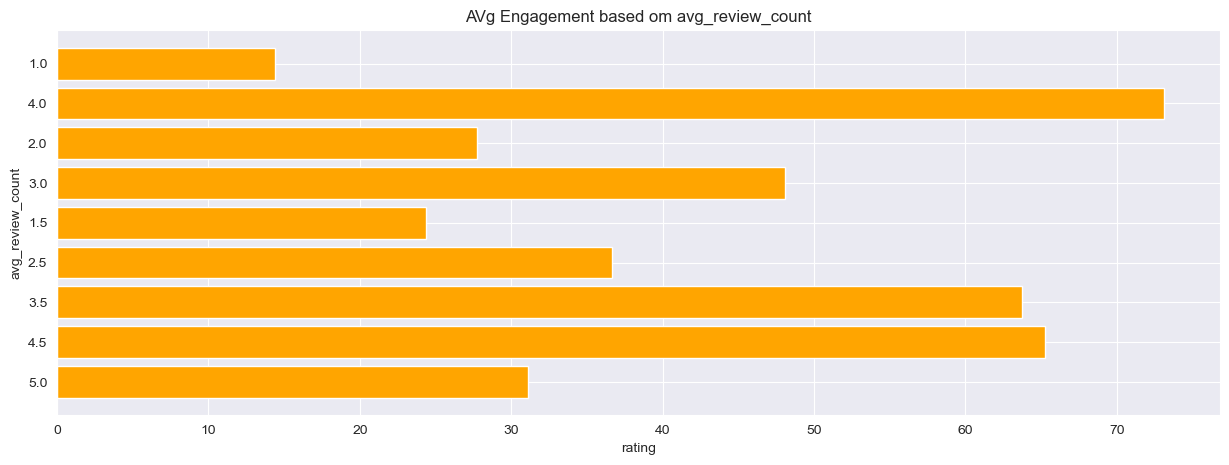

In [15]:
plt.figure(figsize=(15,5))
plt.title("Avg Engagement based on Rating\n")
plt.barh(review_count_df['rating'].astype('str'),review_count_df['avg_review_count'] ,color="orange")
plt.xlabel("rating")
plt.ylabel("avg_review_count")
plt.title("AVg Engagement based om avg_review_count")
plt.show()

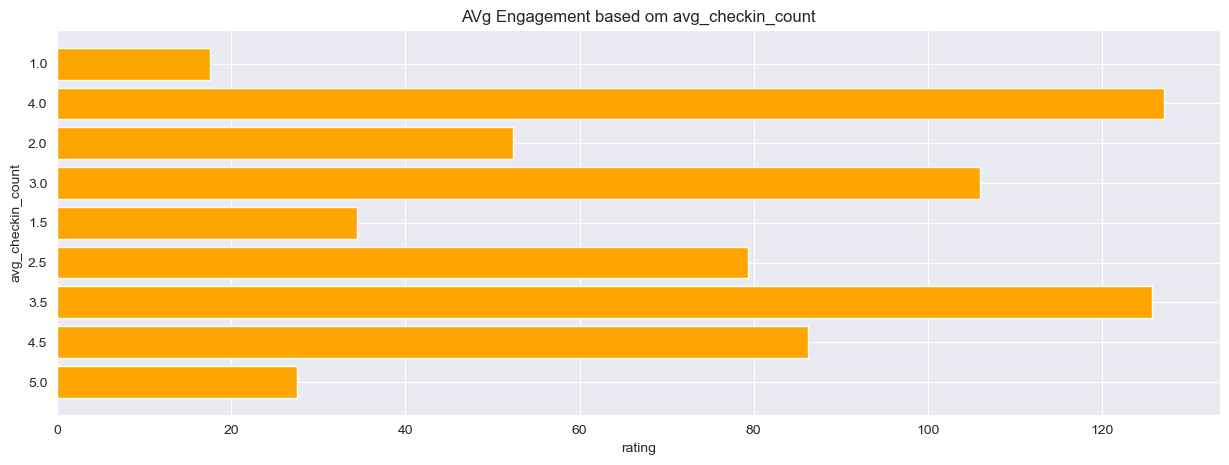

In [16]:
plt.figure(figsize=(15,5))
plt.barh(review_count_df['rating'].astype('str'),review_count_df["avg_checkin_count"] ,color="orange")
plt.xlabel("rating")
plt.ylabel("avg_checkin_count")
plt.title("AVg Engagement based om avg_checkin_count")
plt.show()

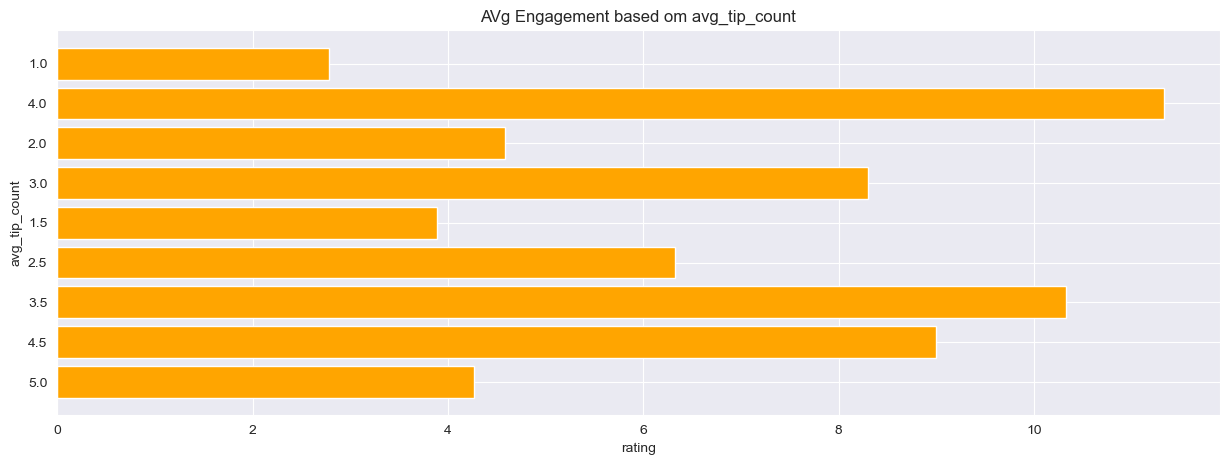

In [17]:
plt.figure(figsize=(15,5))
plt.barh(review_count_df['rating'].astype('str'),review_count_df['avg_tip_count'] ,color="orange")
plt.xlabel("rating")
plt.ylabel("avg_tip_count")
plt.title("AVg Engagement based om avg_tip_count")
plt.show()

In [18]:
# is there  a Correlation between the number of reviews ,tips, and check-in for a business ?
engagement_df=pd.read_sql_query(f"""


    SELECT
        b.business_id,
        SUM(b.review_count) AS review_count,
        AVG(b.stars) AS avg_rating,
        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
        SUM(tip.tip_count) AS tip_count
    FROM
        business b
    LEFT JOIN
        checkin cc
        ON b.business_id = cc.business_id
    LEFT JOIN
        (
            SELECT
                business_id,
                COUNT(business_id) AS tip_count
            FROM tip
            GROUP BY business_id
            ORDER BY tip_count
        ) AS tip
        ON b.business_id = tip.business_id
    WHERE
        b.business_id IN {tuple(ids['business_id'])}
    GROUP BY
        b.business_id
""", engine).dropna()

In [19]:
engagement_df[['review_count','checkin_count','tip_count']].corr()

,review_count,checkin_count,tip_count
review_count,1.000000,0.626884,0.766321
checkin_count,0.626884,1.000000,0.772088
tip_count,0.766321,0.772088,1.000000


<Axes: >

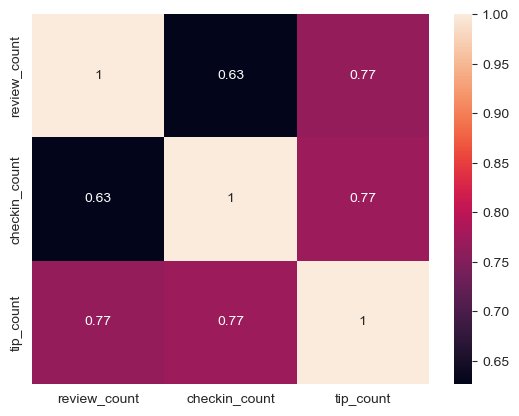

In [20]:
sns.heatmap(engagement_df[['review_count','checkin_count','tip_count']].corr(),annot=True)

In [21]:
# Is there a difference in the user Engagement (reviews,tips,and checkin) between high-rated and low-rated business  ?

engagement_df2=pd.read_sql_query(f"""


    SELECT
        b.business_id,
        SUM(b.review_count) AS review_count,
        AVG(b.stars) AS avg_rating,
        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
        SUM(tip.tip_count) AS tip_count,
        CASE
        WHEN AVG(b.stars) >= 3.5 THEN 'High-Rated'
        ELSE 'Low-Rated'
    END AS category

    FROM
        business b
    LEFT JOIN
        checkin cc
        ON b.business_id = cc.business_id
    LEFT JOIN
        (
            SELECT
                business_id,
                COUNT(business_id) AS tip_count
            FROM tip
            GROUP BY business_id
            ORDER BY tip_count
        ) AS tip
        ON b.business_id = tip.business_id
    WHERE
        b.business_id IN {tuple(ids['business_id'])}
    GROUP BY
        b.business_id
""", engine).dropna()

In [22]:
# Is there a difference in the user engagement (review,tip, and check-in) between high-rated and low-rated business ?

engagement_df2.groupby("category")[["review_count","tip_count","checkin_count"]].mean()


,review_count,tip_count,checkin_count
category,,,
High-Rated,72.291062,10.162766,122.066641
Low-Rated,42.123420,6.541689,88.880828


In [23]:
# function to calculate the success score based on the avg rating and total review count

def calculate_success_metric(df):
    success_score = []
    for i,row in df.iterrows():
        score = row['avg_rating'] * np.log(row['review_count']+1)
        success_score.append(score)
    return success_score

In [24]:
# How do the success metric [review_count or avg_rating] of restaurent vary across different states and cities ?

city_df=pd.read_sql_query(f"""SELECT city,state,AVG(latitude) AS latitude,AVG(longitude) AS longitude,AVG(stars) AS avg_rating,SUM(review_count) AS review_count,COUNT(*) AS restaurant_count FROM business
WHERE business_id IN {tuple(ids['business_id'])}
GROUP BY state,city
ORDER BY review_count DESC
LIMIT 10 """,engine)


In [25]:
city_df['success_score'] = calculate_success_metric(city_df)
city_df

,city,state,latitude,longitude,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,39.982274,-75.150003,3.532312,175606.0,3002,42.656211
1,Tampa,FL,28.001731,-82.476943,3.568274,104751.0,1721,41.246934
2,Indianapolis,IN,39.802349,-86.141398,3.412111,92639.0,1701,39.022521
3,Tucson,AZ,32.233891,-110.936402,3.383885,91672.0,1421,38.664208
4,Nashville,TN,36.142252,-86.770107,3.491465,87100.0,1406,39.714800
5,New Orleans,LA,29.961270,-90.075371,3.694472,69309.0,1013,41.179856
6,Saint Louis,MO,38.616387,-90.302794,3.414303,51490.0,811,37.042331
7,Reno,NV,39.507601,-119.806460,3.479695,48569.0,591,37.548563
8,Edmonton,AB,53.526310,-113.514226,3.509367,45986.0,1548,37.676963
9,Boise,ID,43.608537,-116.239164,3.558824,36104.0,561,37.346958


In [26]:
# Create a base map
m = folium.Map(location=[city_df['latitude'].mean(),city_df['longitude'].mean()],zoom_start=4)
# define a color scale
color_scale = folium.LinearColormap(colors=['red','yellow','green'],
                                    vmin=city_df['success_score'].min(),
                                    vmax=city_df['success_score'].max())
# Add marker to the map
for i ,row in city_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'],row['longitude']],
        radius=5,
        color=color_scale(row['success_score']),
        fill=True,
        fill_color = color_scale(row['success_score']),
        fill_opacity=0.7,
        popup=f"Success Score: {row['success_score']}"
    ).add_to(m)

# Add color scale to the map
m.add_child(color_scale)

In [27]:
# Are there any pattern in user engagement over time for successfu business compared to less succesful ones?
# Are there any seasonal trends in the user engagements for restaurents?

# high_rated_engagement = pd.read_sql_query(f"""SELECT review.month_year,tip.tip_count FROM (SELECT strftime('%-%Y',date) as month_year,COUNT(*) as review_count FROM review WHERE business_id IN {tuple(ids['business_id'])} AND stars >= 3.5 GROUP BY month_year ORDER BY month_year) as review
# JOIN
# (SELECT AVG(b.stars),strftime('%m-%Y',tip.date) as month_year,COUNT(*) as tip_count FROM tip JOIN business b
# ON tip.business_id = b.business_id
# WHERE tip.business_id IN {tuple(ids['business_id'])} AND b.stars >= 3.5
# GROUP BY month_year
# ORDER BY month_year) as tip
# ON review.month_year = tip.month_year""",engine)

high_rated_engagement = pd.read_sql_query(
    f"""
    SELECT
        r.month_year,
        r.review_count,
        t.tip_count
    FROM (
        SELECT
            DATE_FORMAT(date, '%%m-%%Y') AS month_year,
            COUNT(*) AS review_count
        FROM review
        WHERE business_id IN {tuple(ids['business_id'])}
          AND stars >= 3.5
        GROUP BY month_year
        ORDER BY month_year
    ) AS r
    JOIN (
        SELECT

            DATE_FORMAT(tip.date, '%%m-%%Y') AS month_year,
            COUNT(*) AS tip_count,
            AVG(b.stars)

        FROM tip
        JOIN business b
            ON tip.business_id = b.business_id
        WHERE tip.business_id IN {tuple(ids['business_id'])}
          AND b.stars >= 3.5
        GROUP BY month_year
    ) AS t
        ON r.month_year = t.month_year """,
    engine
)


In [28]:
low_rated_engagement = pd.read_sql_query(
    f"""
    SELECT
        r.month_year,
        r.review_count,
        t.tip_count
    FROM (
        SELECT
            DATE_FORMAT(date, '%%m-%%Y') AS month_year,
            COUNT(*) AS review_count
        FROM review
        WHERE business_id IN {tuple(ids['business_id'])}
          AND stars < 3.5
        GROUP BY month_year
        ORDER BY month_year
    ) AS r
    JOIN (
        SELECT
            DATE_FORMAT(tip.date, '%%m-%%Y') AS month_year,
            COUNT(*) AS tip_count,
            AVG(b.stars)
        FROM tip
        JOIN business b
            ON tip.business_id = b.business_id
        WHERE tip.business_id IN {tuple(ids['business_id'])}
          AND b.stars < 3.5
        GROUP BY month_year
        ORDER BY month_year
    ) AS t
        ON r.month_year = t.month_year """,
    engine
)

In [29]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,1218,79
1,01-2011,2171,621
2,01-2012,3086,1321
3,01-2013,3801,1230
4,01-2014,4973,1357
...,...,...,...
149,12-2017,10161,1477
150,12-2018,12870,1163
151,12-2019,13756,1161
152,12-2020,11294,937


In [30]:
low_rated_engagement

,month_year,review_count,tip_count
0,01-2010,613,25
1,01-2011,1103,297
2,01-2012,1748,538
3,01-2013,2196,548
4,01-2014,2769,607
...,...,...,...
149,12-2017,5970,441
150,12-2018,7574,338
151,12-2019,7591,275
152,12-2020,5014,148


In [31]:
time_rating = pd.read_sql_query(f"""SELECT DATE_FORMAT(date, '%%m-%%Y') AS month_year,AVG(stars) as average_rating FROM review WHERE business_id IN {tuple(ids['business_id'])} GROUP BY month_year
ORDER BY month_year""",engine)

In [32]:
time_rating

,month_year,average_rating
0,01-2006,4.0000
1,01-2007,3.8974
2,01-2008,3.6040
3,01-2009,3.6907
4,01-2010,3.7242
...,...,...
198,12-2017,3.6134
199,12-2018,3.6087
200,12-2019,3.6652
201,12-2020,3.8337


In [33]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year',inplace=True)
time_rating = time_rating[time_rating['month_year'] > '2017']

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year',inplace=True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year',inplace=True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']

In [34]:
high_rated_engagement['avg_rating'] = time_rating['average_rating'].values

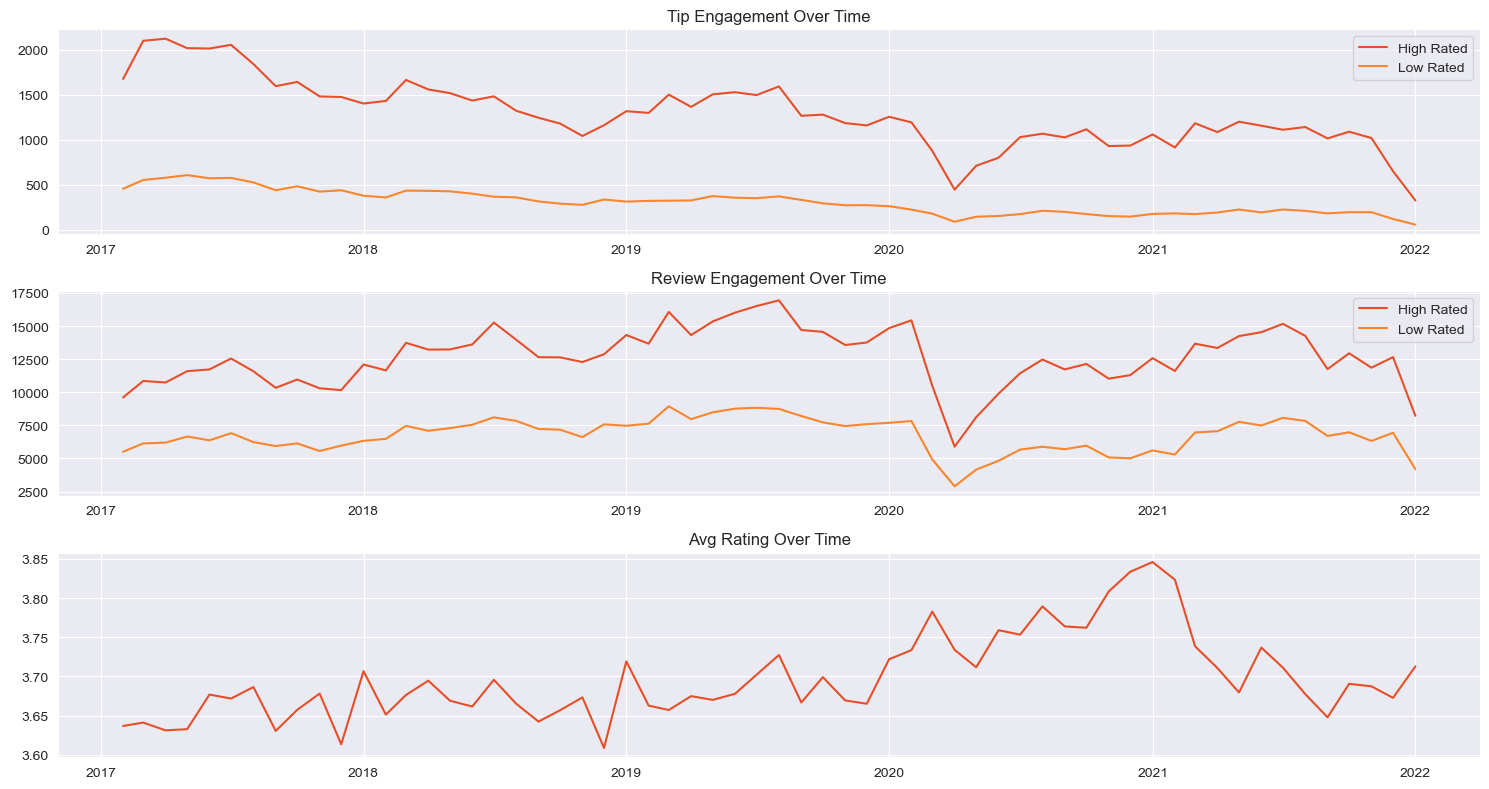

In [35]:
plt.figure(figsize=(15,8))

plt.subplot(3,1,1)
plt.title('Tip Engagement Over Time')
plt.plot(
    high_rated_engagement['month_year'],
    high_rated_engagement['tip_count'],
    label='High Rated',
    color='#E54F29'
)
plt.plot(
    low_rated_engagement['month_year'],
    low_rated_engagement['tip_count'],
    label='Low Rated',
    color='#F8862C'
)
plt.legend()

plt.subplot(3,1,2)
plt.title('Review Engagement Over Time')
plt.plot(
    high_rated_engagement['month_year'],
    high_rated_engagement['review_count'],
    label='High Rated',
    color='#E54F29'
)
plt.plot(
    low_rated_engagement['month_year'],
    low_rated_engagement['review_count'],
    label='Low Rated',
    color='#F8862C'
)
plt.legend()

plt.subplot(3,1,3)
plt.title('Avg Rating Over Time')
plt.plot(
    time_rating['month_year'],
    time_rating['average_rating'],
    color='#E54F29'
)

plt.tight_layout()
plt.show()

In [36]:
tip_high_rated = high_rated_engagement[['month_year','tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year','review_count']].set_index('month_year')
rating_df = time_rating[['month_year',"average_rating"]].set_index('month_year')


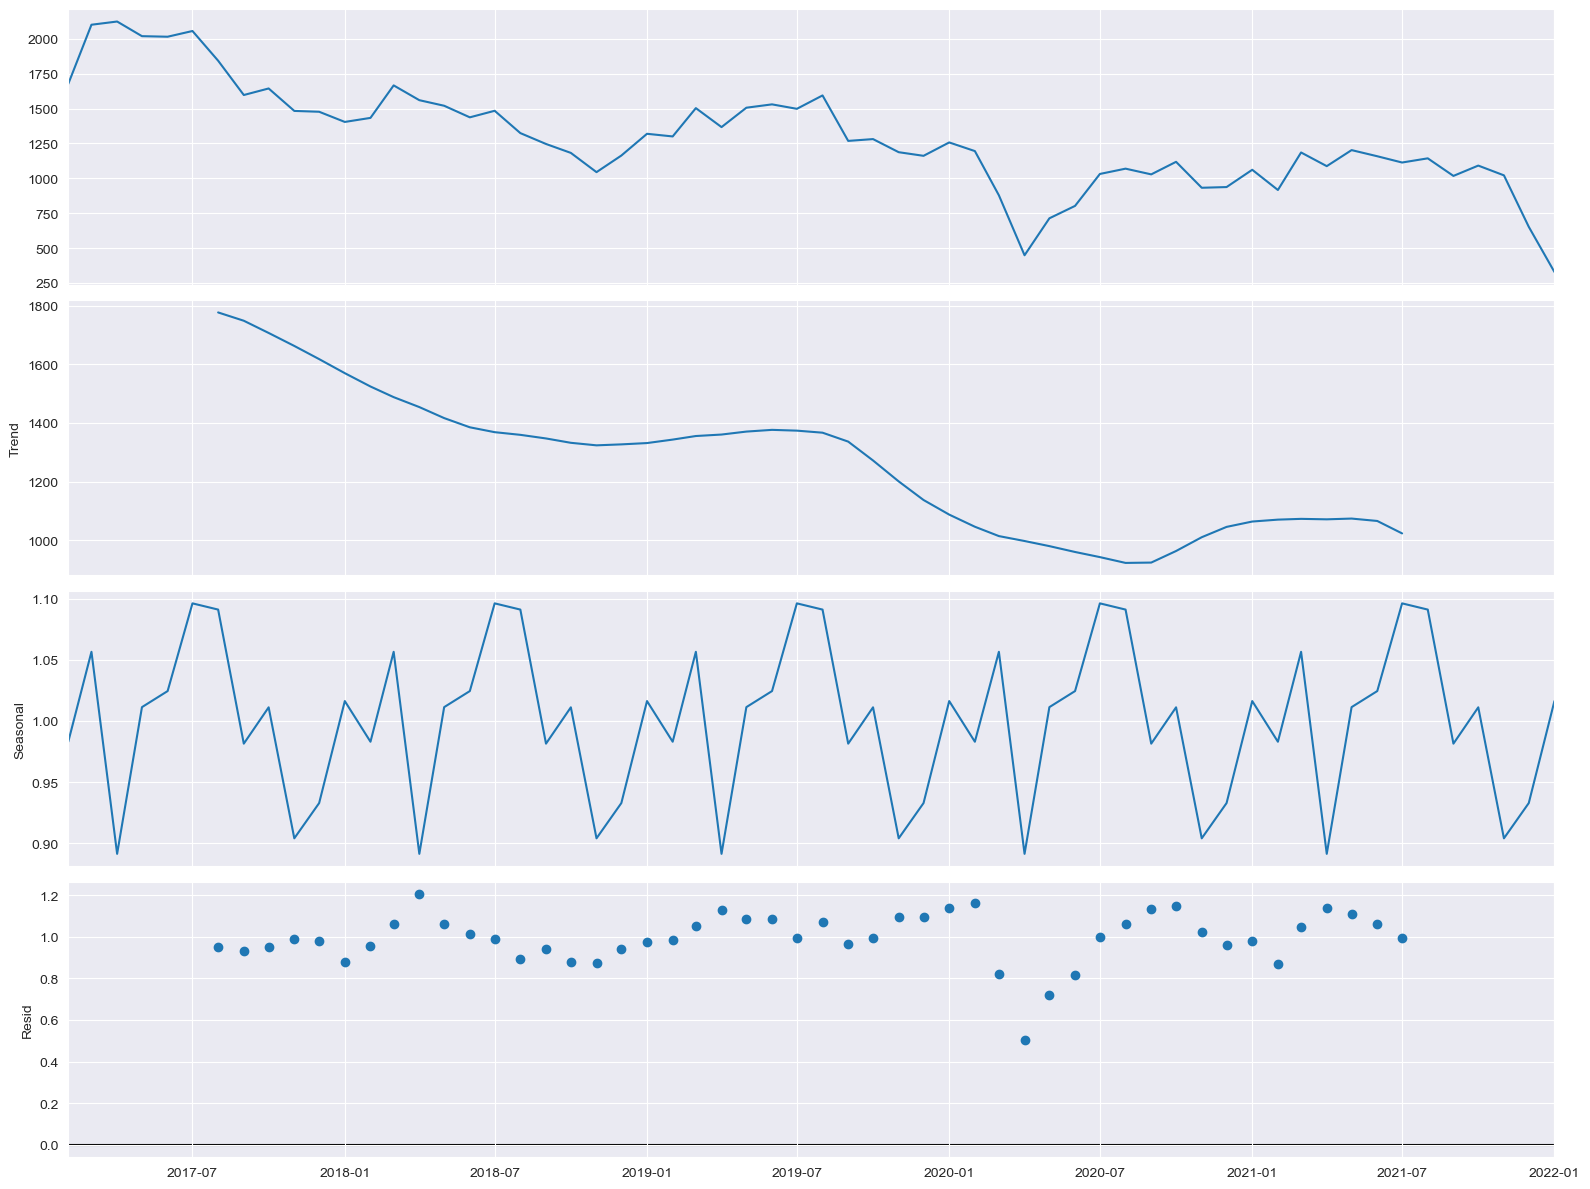

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose
multiplicative_decomposition = seasonal_decompose(tip_high_rated,model='multiplicative',period=12)

plt.rcParams.update({'figure.figsize':(16,12)})
multiplicative_decomposition.plot()
plt.show()

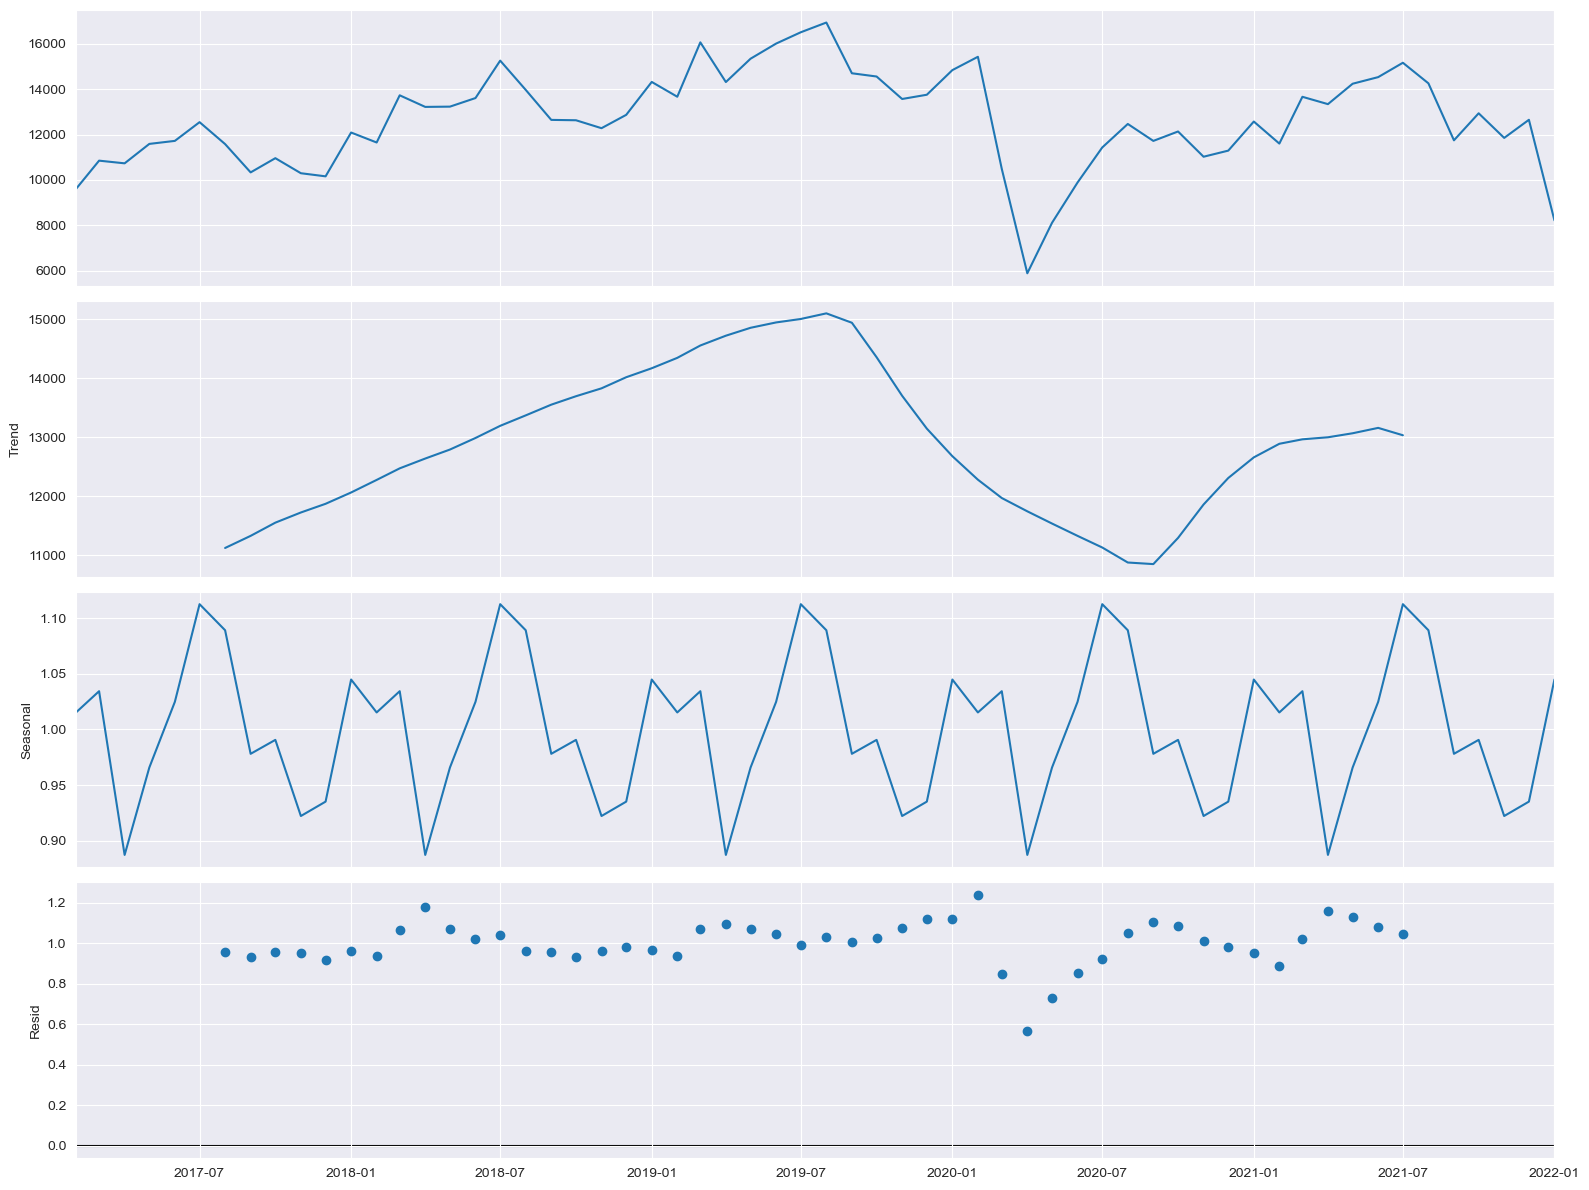

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
multiplicative_decomposition = seasonal_decompose(review_high_rated,model='multiplicative',period=12)

plt.rcParams.update({'figure.figsize':(16,12)})
multiplicative_decomposition.plot()
plt.show()

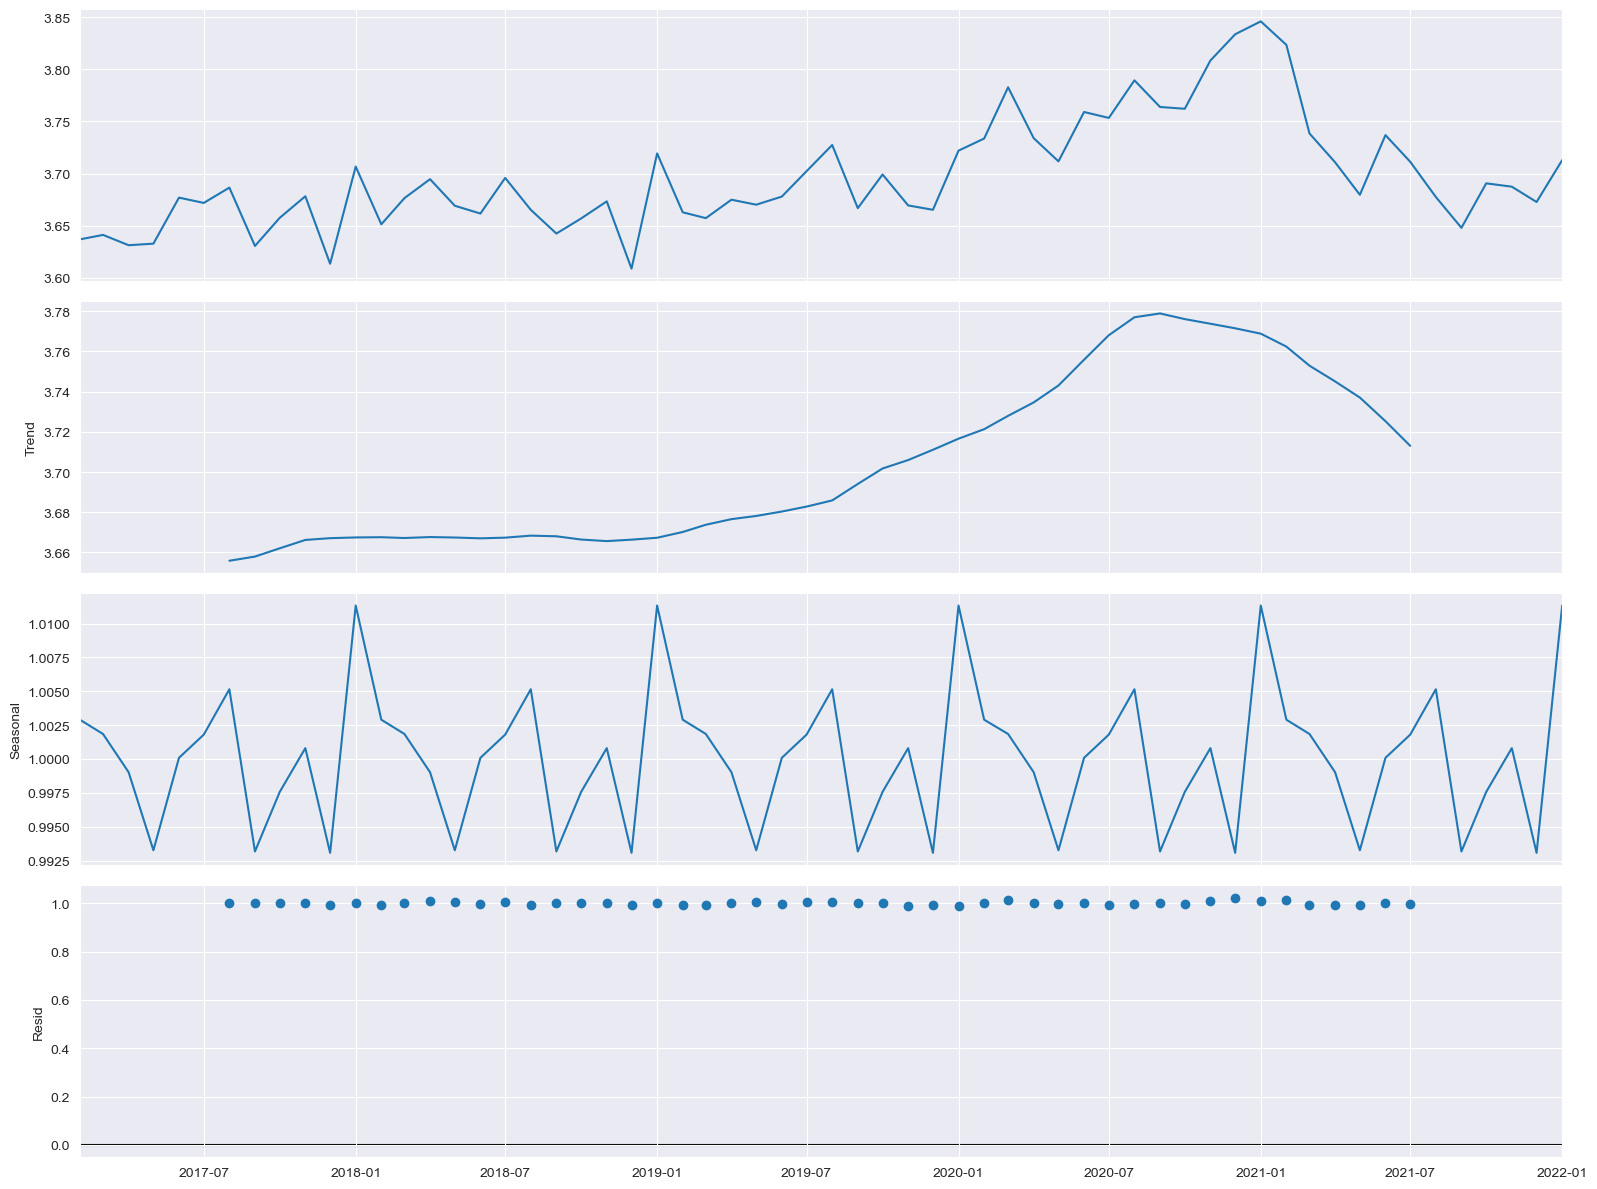

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose
multiplicative_decomposition = seasonal_decompose(rating_df,model='multiplicative',period=12)

plt.rcParams.update({'figure.figsize':(16,12)})
multiplicative_decomposition.plot()
plt.show()

In [40]:
# How does the sentiment of reviews and tips useful ,funny,cool) correlate with the success metrics of restaurents?

sentiment_df=pd.read_sql_query(f"""select b.business_id,avg(b.stars) as avg_rating,sum(review_count) as review_count,sum(s.useful_count) as useful_count,sum(s.funny_count) as funny_count,sum(s.cool_count) as cool_count from
(select business_id,sum(useful) as useful_count,sum(funny) as funny_count,sum(cool) as cool_count from review group by business_id) as s
join business b on b.business_id = s.business_id
where b.business_id  IN {tuple(ids['business_id'])}
group by b.business_id
order by review_count""",engine)

sentiment_df = remove_outlier(sentiment_df,'review_count')
sentiment_df = remove_outlier(sentiment_df,'useful_count')
sentiment_df = remove_outlier(sentiment_df,'funny_count')
sentiment_df = remove_outlier(sentiment_df,'cool_count')


In [41]:
sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

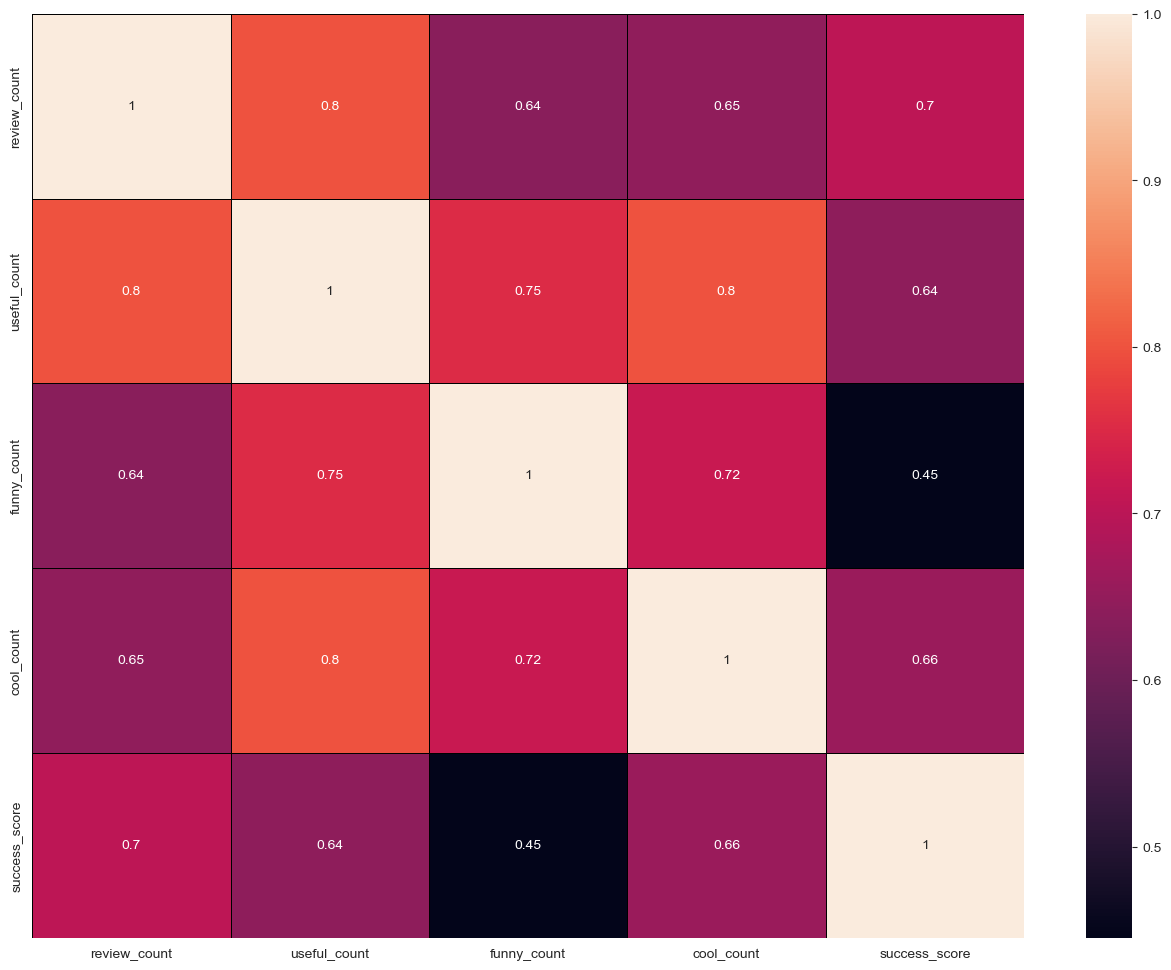

In [42]:
sns.heatmap(sentiment_df.iloc[:,2:].corr(),annot=True,linewidths=0.5,linecolor='black')
plt.show()

In [43]:
# Is there any difference in engagement of elite users and non-elite users?
elite_df = pd.read_sql_query("""select elite,count(*) as row_count, sum(review_count) as total_review_count from (select case when elite = '' then 'Not Elite' else 'Elite' end as elite,u.review_count from user u) as user_elite group by elite""",engine)

In [44]:
elite_df

,elite,row_count,total_review_count
0,Elite,91198,20484441.0
1,Not Elite,1896699,26021235.0


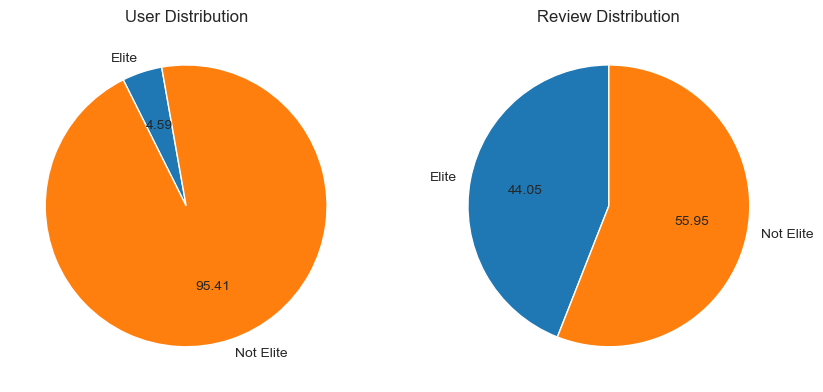

In [45]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title('User Distribution')
plt.pie(elite_df['row_count'],labels=elite_df['elite'],startangle=100,autopct='%.2f')

plt.subplot(1,2,2)
plt.title('Review Distribution')
plt.pie(elite_df['total_review_count'],labels=elite_df['elite'],startangle=90,autopct='%.2f')
plt.show()





In [48]:
# What are the business hours for restaurents?

# Review engagement by hour
review_engagement = pd.read_sql_query("""
SELECT
    HOUR(date) AS hour,
    COUNT(*) AS review_count
FROM review
GROUP BY hour
ORDER BY hour
""", engine)

# Tip engagement by hour
tip_management = pd.read_sql_query("""
SELECT
    HOUR(date) AS hour,
    COUNT(*) AS tip_count
FROM tip
GROUP BY hour
ORDER BY hour
""", engine)

# Checkin engagement by hour
checkin = pd.read_sql_query("""
SELECT date
FROM checkin
""", engine)

checkin_engagement = []

for i in checkin['date']:
    for j in i.split(','):
        hour = datetime.strptime(j.strip(), "%Y-%m-%d %H:%M:%S").hour
        checkin_engagement.append(hour)

checkin_engagement = (
    pd.DataFrame(checkin_engagement, columns=['hour'])
    .groupby('hour')
    .size()
    .reset_index(name='checkin_count')
)
checkin_engagement



,hour,checkin_count
0,0,1155092
1,1,935985
2,2,669574
3,3,437035
4,4,264905
5,5,152476
6,6,85066
7,7,52295
8,8,35589
9,9,37079


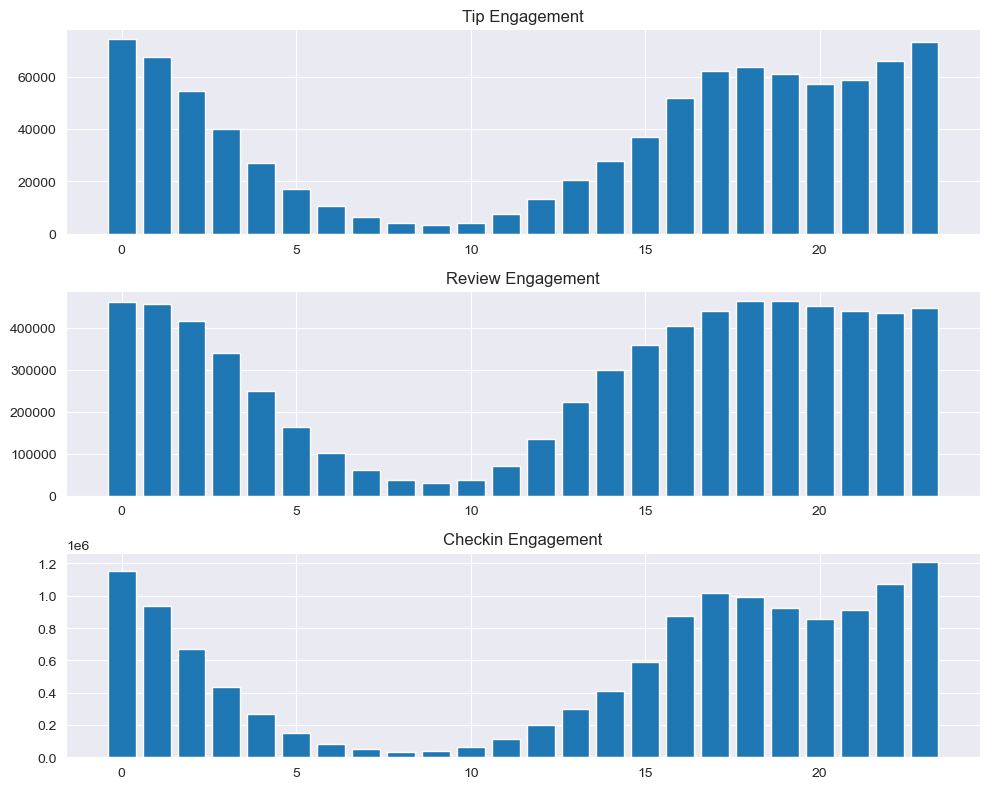

In [47]:
plt.figure(figsize=(10, 8))

# Tip Engagement
plt.subplot(3, 1, 1)
plt.title('Tip Engagement')
plt.bar(tip_management['hour'], tip_management['tip_count'])

# Review Engagement
plt.subplot(3, 1, 2)
plt.title('Review Engagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'])

# Checkin Engagement
plt.subplot(3, 1, 3)
plt.title('Checkin Engagement')
plt.bar(checkin_engagement['hour'], checkin_engagement['checkin_count'])

plt.tight_layout()
plt.show()